# Medium Inversions (LEVIATHAN)
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 95 -m 95 -l 90`.

In [ ]:
library(ggplot2)
library(ggpattern)
library(dplyr)
library(ggpubr)
.size <- "medium"

These are the setup functions that process that data.

In [ ]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("../simulated_variants/setup_inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("../simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample90/inversions.bedpe", sep = "/")
    poolfile <- paste("../simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop90/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- "pooled" #paste("pooled", depth, size_treatment, sep = "_")
    }
    outdf <- rbind(true_inversions, sample_inversions, pooled_inversions)
    outdf$depth <- depth
    return(outdf)
}

read_all_data <- function(size_treatment){
    depth <- 0.5
    .data <- read_data(size_treatment, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(.size, i))    
    }
    return(.data)
}

In [11]:
SV <- read_all_data("large")
samplesSV <- SV[SV$sample != "simulated_inversions",]
head(samplesSV)

,contig,position_start,position_end,sample,depth
,<chr>,<int>,<dbl>,<chr>,<dbl>
9,2L,11529164,15060030,pooled,0.5
10,3L,176549,2301734,pooled,0.5
11,2R,1439996,4186469,pooled,0.5
28,2L,20404849,20474311,sample_08,2.0
29,3R,22722815,22831351,sample_08,2.0
30,2L,17056242,17424245,sample_04,2.0


A function to wrap all these other functions for simplicity.

In [12]:
summarize_performance <- function(inventory, .size){
    depth <- 0.5
    .data <- read_data(.size, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(.size, i))    
    }
    .performance <- assess_performace(.data, inventory)
    .sampleplot <- plot_samples_matrix(.performance, .size)
    .poolplot <- plot_pools_matrix(.performance, .size)
    .inversionplot <- plot_inversions(.data, .size)
    show(
        ggarrange(
            ggarrange(.sampleplot, .poolplot, ncol = 2, labels = c("A", "B"), common.legend = T),
            .inversionplot, nrow = 2, labels = c("","C"), heights = c(1.5,4)
        )
    )
    return(.performance)
}

Read in the sample and pool simulation inventory

In [ ]:
inventory <- rbind(
    filter(read.table("../inversion_simulations.inventory", header = T), size == .size),
    filter(read.table("../inversion_simulations.pool.inventory", header = T), size == .size)
)
inventory <- rename(inventory, "simulated" = "present", "zygosity" = "state")

# set a default to false negatives, to be updated to true positives when conditions are met
inventory$assessment <- ifelse(inventory$simulated, "false negative", "true negative")
inventory$sample <- gsub("pool", "pooled", inventory$sample)

# add depths to performance
# arrange() is for sanity-checking
performance <- inventory
performance$depth <- 0.5
for(i in c(2, 5, 10, 20)){
    inventory$depth <- i
    performance <- rbind(performance, inventory)
}
performance <- arrange(performance, sample, contig, inversion)

## read in truth data to transfer inversion breakpoints
x <- read_data(.size, 0.5)
for(i in c(2,5,10,20)){
    x <- rbind(x, read_data(.size, i))
}
x <- arrange(x, sample, contig, position_start, depth)

truth <- group_by(x[x$sample == "simulated_inversions",], contig, depth) %>% mutate(inversion = 1:n()) %>% ungroup()
truth <- truth[, c(1,6,2,3,5)]

# merge it all together
performance <- merge(performance,truth, by = c("contig", "inversion", "depth"))
performance$id <- as.integer(as.factor(performance$position_start))
performance <- arrange(performance[, c(1,2,11,3,4:10)], contig, inversion, sample, depth)
head(performance, 15)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<int>,<dbl>
1,2L,1,1,0.5,pooled,medium,TRUE,hom,false negative,1591146,1776073
2,2L,1,1,2.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
3,2L,1,1,5.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
4,2L,1,1,10.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
5,2L,1,1,20.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
6,2L,1,1,0.5,sample_01,medium,TRUE,hom,false negative,1591146,1776073
7,2L,1,1,2.0,sample_01,medium,TRUE,hom,false negative,1591146,1776073
8,2L,1,1,5.0,sample_01,medium,TRUE,hom,false negative,1591146,1776073
9,2L,1,1,10.0,sample_01,medium,TRUE,hom,false negative,1591146,1776073


### Assess the performance of identified inversions

In [14]:
false_positives <- samplesSV[0,]

for(i in 1:nrow(samplesSV)){
    .row <- samplesSV[i,]
    query <- which(
        performance$sample == .row$sample &
        performance$depth == .row$depth &
        performance$contig == .row$contig &
        performance$position_start - 50 <= .row$position_start &
        performance$position_end + 50 >= .row$position_end
    )
    if(length(query) > 0 && performance$simulated[query]){
        performance$assessment[query] <- "true positive"
    } else {
        performance$assessment[query] <- "false positive"
        false_positives <- rbind(false_positives, .row)
    }
}
head(performance)
head(false_positives)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<int>,<dbl>
1,2L,1,1,0.5,pooled,medium,TRUE,hom,false negative,1591146,1776073
2,2L,1,1,2.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
3,2L,1,1,5.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
4,2L,1,1,10.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
5,2L,1,1,20.0,pooled,medium,TRUE,hom,false negative,1591146,1776073
6,2L,1,1,0.5,sample_01,medium,TRUE,hom,false negative,1591146,1776073


,contig,position_start,position_end,sample,depth
,<chr>,<int>,<dbl>,<chr>,<dbl>
9,2L,11529164,15060030,pooled,0.5
10,3L,176549,2301734,pooled,0.5
11,2R,1439996,4186469,pooled,0.5


This is extra formatting we need to do to get it to plot correctly

In [15]:
performance$sample <- gsub("sample_", "", performance$sample)
performance$sample <- gsub("pooled", "11", performance$sample)
performance$sample <- as.integer(performance$sample)

simulated_for_plot <- truth
simulated_for_plot$assessment <- "true positive"
simulated_for_plot$sample <- 0
simulated_for_plot <- simulated_for_plot[simulated_for_plot$depth == 20,]
head(simulated_for_plot)

contig,inversion,position_start,position_end,depth,assessment,sample
<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
2L,1,1591146,1776073,20,true positive,0
2L,2,6436329,6636405,20,true positive,0
2L,3,17056243,17424245,20,true positive,0
2L,4,20404853,20474308,20,true positive,0
2R,1,9640874,9978281,20,true positive,0
2R,2,15862083,16302028,20,true positive,0


### Single-Sample Detection
Let's first visualize what detection looked like across the genome. Here, we facet across contigs and show all the depths at once.

In [25]:
plot_inversions <- function(data, groundtruth, size_treatment){
    options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
    .tbl <- filter(data, assessment == "true positive") %>% select(contig, inversion, position_start, position_end, depth, assessment, sample)
    
    rbind(.tbl, groundtruth) %>%

    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end,
            color = as.factor(depth),
        )
    ) +
        geom_linerange(position = position_dodge(0.7), linewidth = 1.5) +
        coord_flip() +
        scale_color_brewer(name = "sequencing depth", palette = "Set2") +
        scale_x_continuous(breaks = 0:11,limits = c(0, 11)) +
        scale_y_continuous(labels = scales::comma) +
        theme_light() +
        theme(
            panel.grid.major.y = element_blank(),
            legend.position = "top",
            panel.grid.minor.y = element_line(color = "gray80", size = 0.5)
        ) +
        labs(
            title = "Simulated and Called Inversions Across the Genome",
            subtitle = paste0("Size: ", size_treatment),
            y = "genomic position (bp)",
            caption = "sample 0 = groundtruth | sample 11 = pooled"
        ) + 
        facet_grid(cols = vars(contig))
}

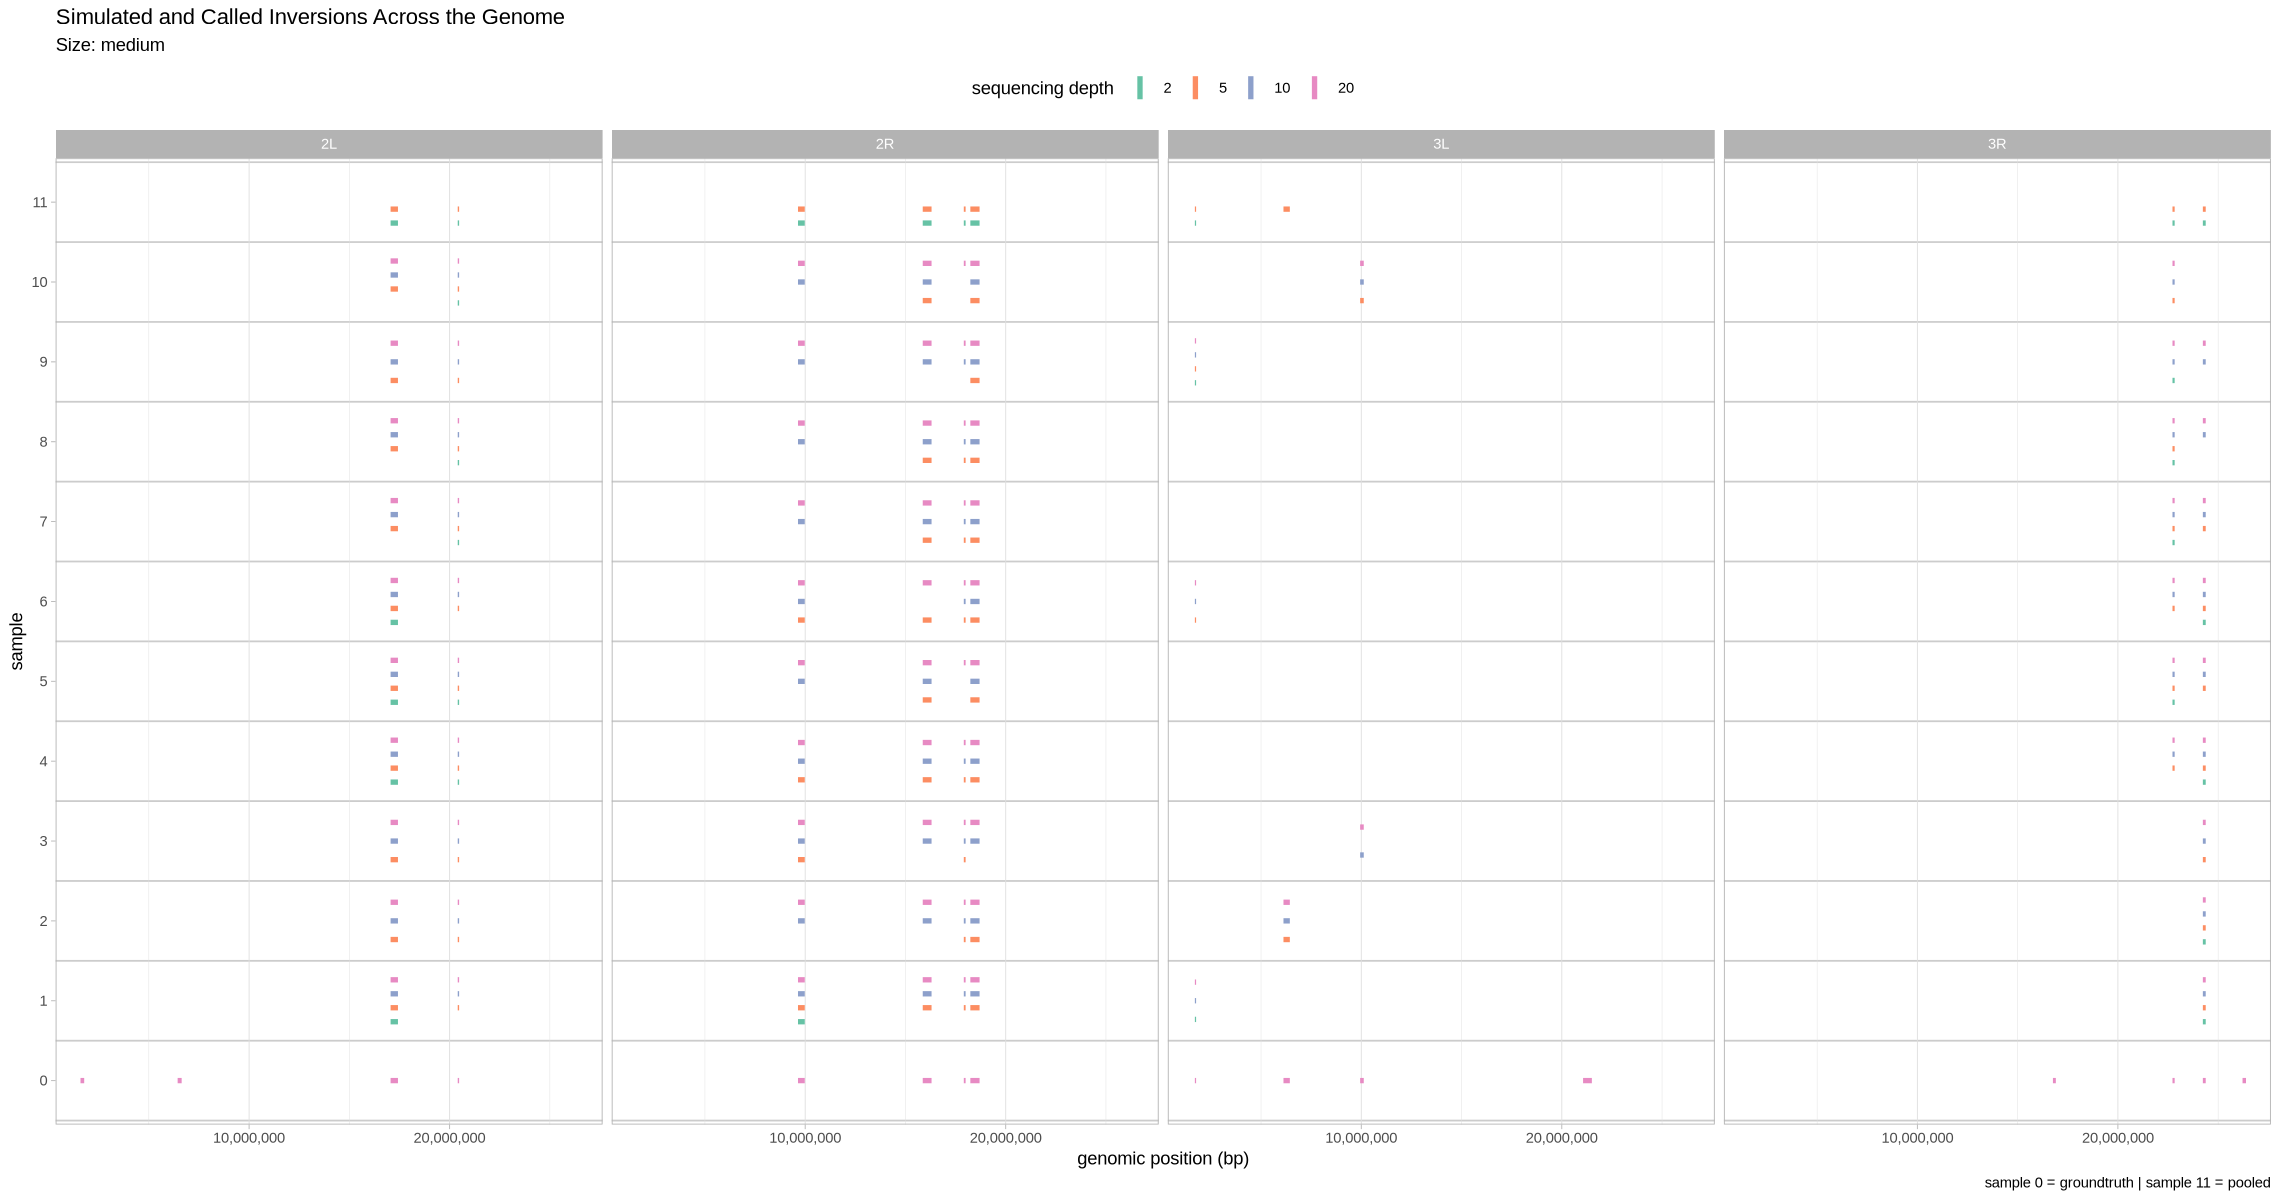

In [26]:
plot_inversions(performance, simulated_for_plot, .size)

What does this look like as a heatmap of true/false positive/negative?

In [18]:
plot_samples_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 10, repr.plot.height = 15)
    .data <- data[data$sample != 11,]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = id, fill = assessment, pattern = zygosity)) +
        geom_tile_pattern(
            pattern_color = NA,
            color = "white",
            pattern_fill = "black",
            pattern_angle = 45,
            pattern_density = 0.5,
            pattern_spacing = 0.025,
            pattern_key_scale_factor = 1
        ) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = paste(size_treatment, "inversions detected in individual samples, as a function of zygotic state.")) +
        scale_fill_manual(values = c("false negative" = "#eaf398ff", "true negative" = "grey70", "true positive" = "#90aed8")) +
        scale_pattern_manual(values = c("het" = "circle", "hom" = "none")) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        coord_cartesian(xlim = c(1, max(data$id)), expand = F) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(rows = vars(depth))
}

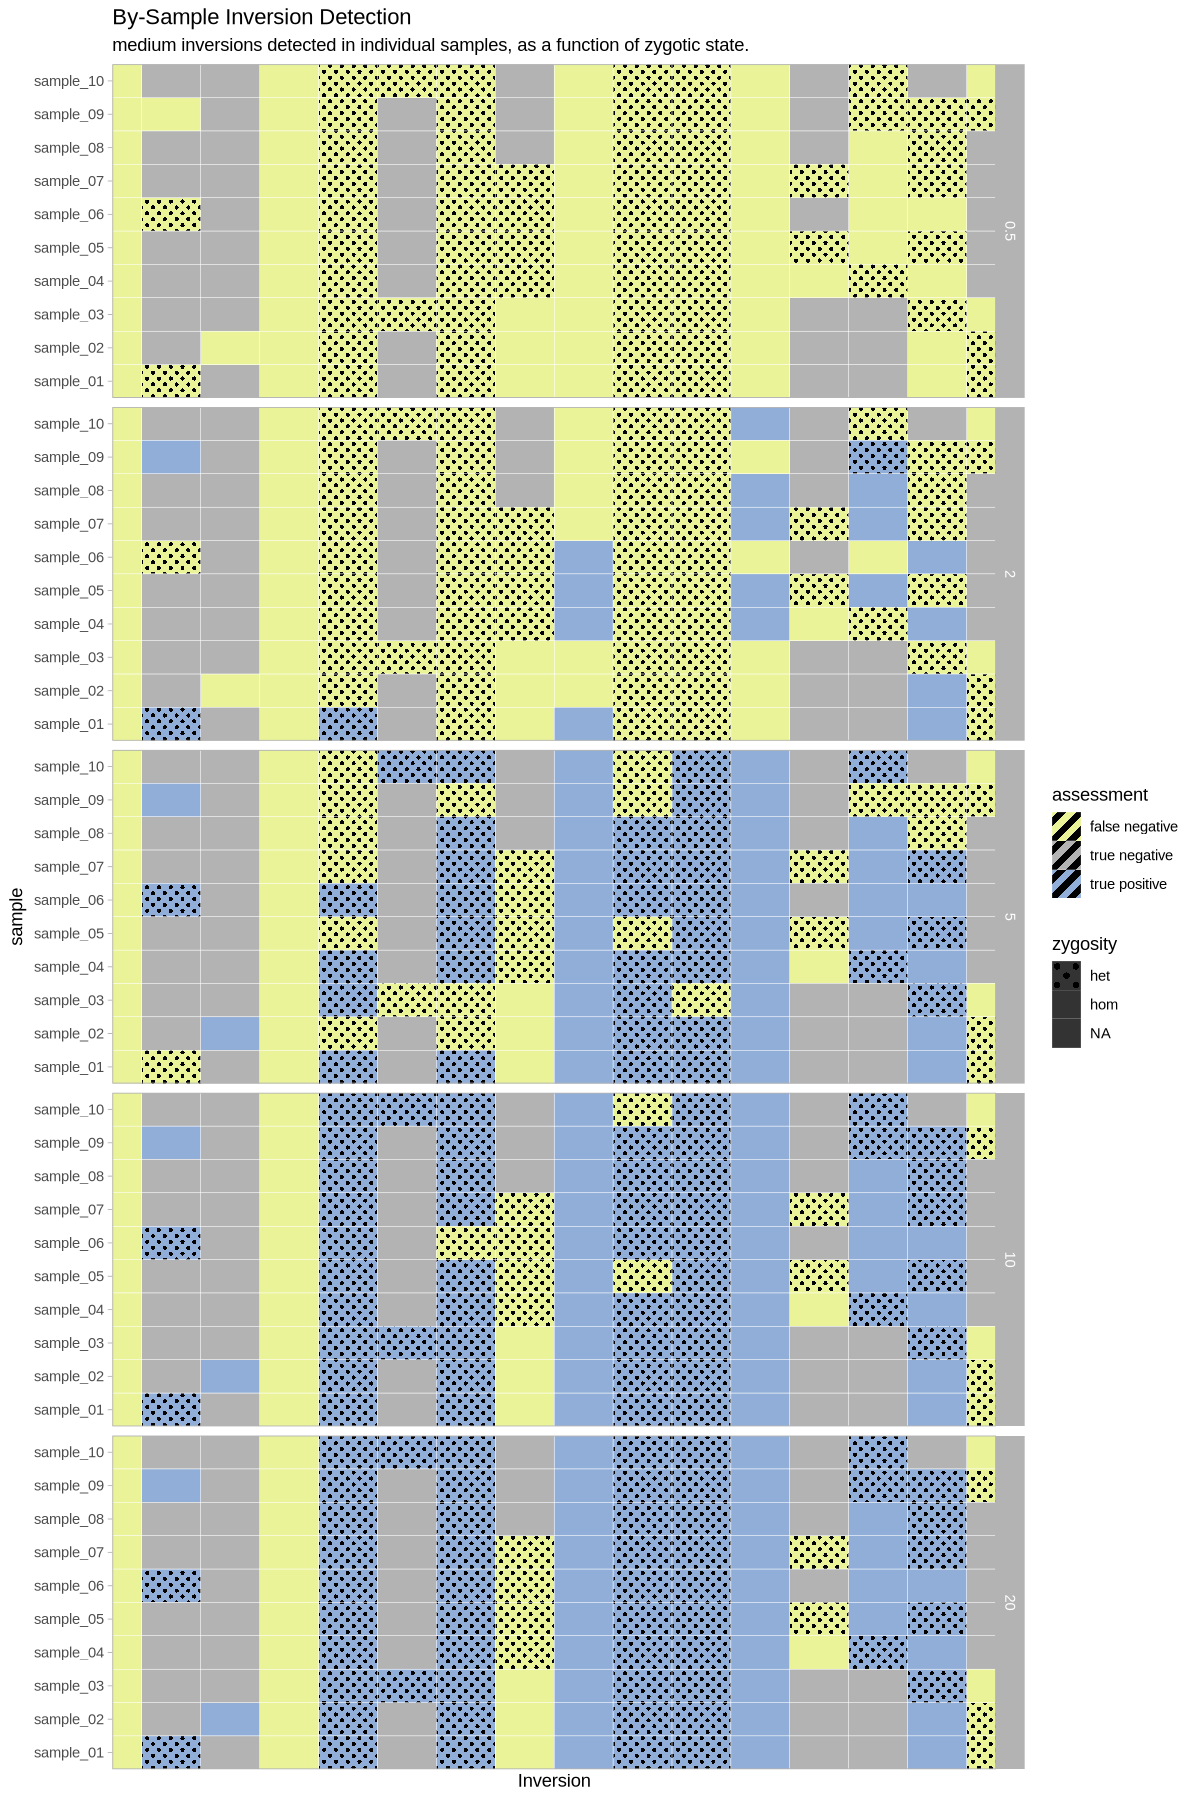

In [19]:
plot_samples_matrix(performance, .size)

### Pooled Sample Detection 

In [20]:
plot_pools_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 15, repr.plot.height = 10)
    .data <- data[data$sample == 11,]
    .data$contig <- gsub("2L", "2L (all homozygous)", .data$contig)
    .data$contig <- gsub("2R", "2R (all heterozygous)", .data$contig)
    .data$contig <- gsub("3L", "3L (inversions common)", .data$contig)
    .data$contig <- gsub("3R", "3R (inversions rare)", .data$contig)
 
    ggplot(.data, aes(y = 1, x = inversion, fill = assessment)) +
        geom_tile(color = "white", linewidth = 1.5) +
        theme_light() +
        labs(title = "Pooled-Sample Detection", subtitle = paste(size_treatment, "inversions detected in sample-pooled data, as a function of inversion frequency in the population.")) +
        scale_fill_manual(values = c("false negative" = "grey70", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        coord_cartesian(xlim = c(1, max(data$inversion)), expand = F) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

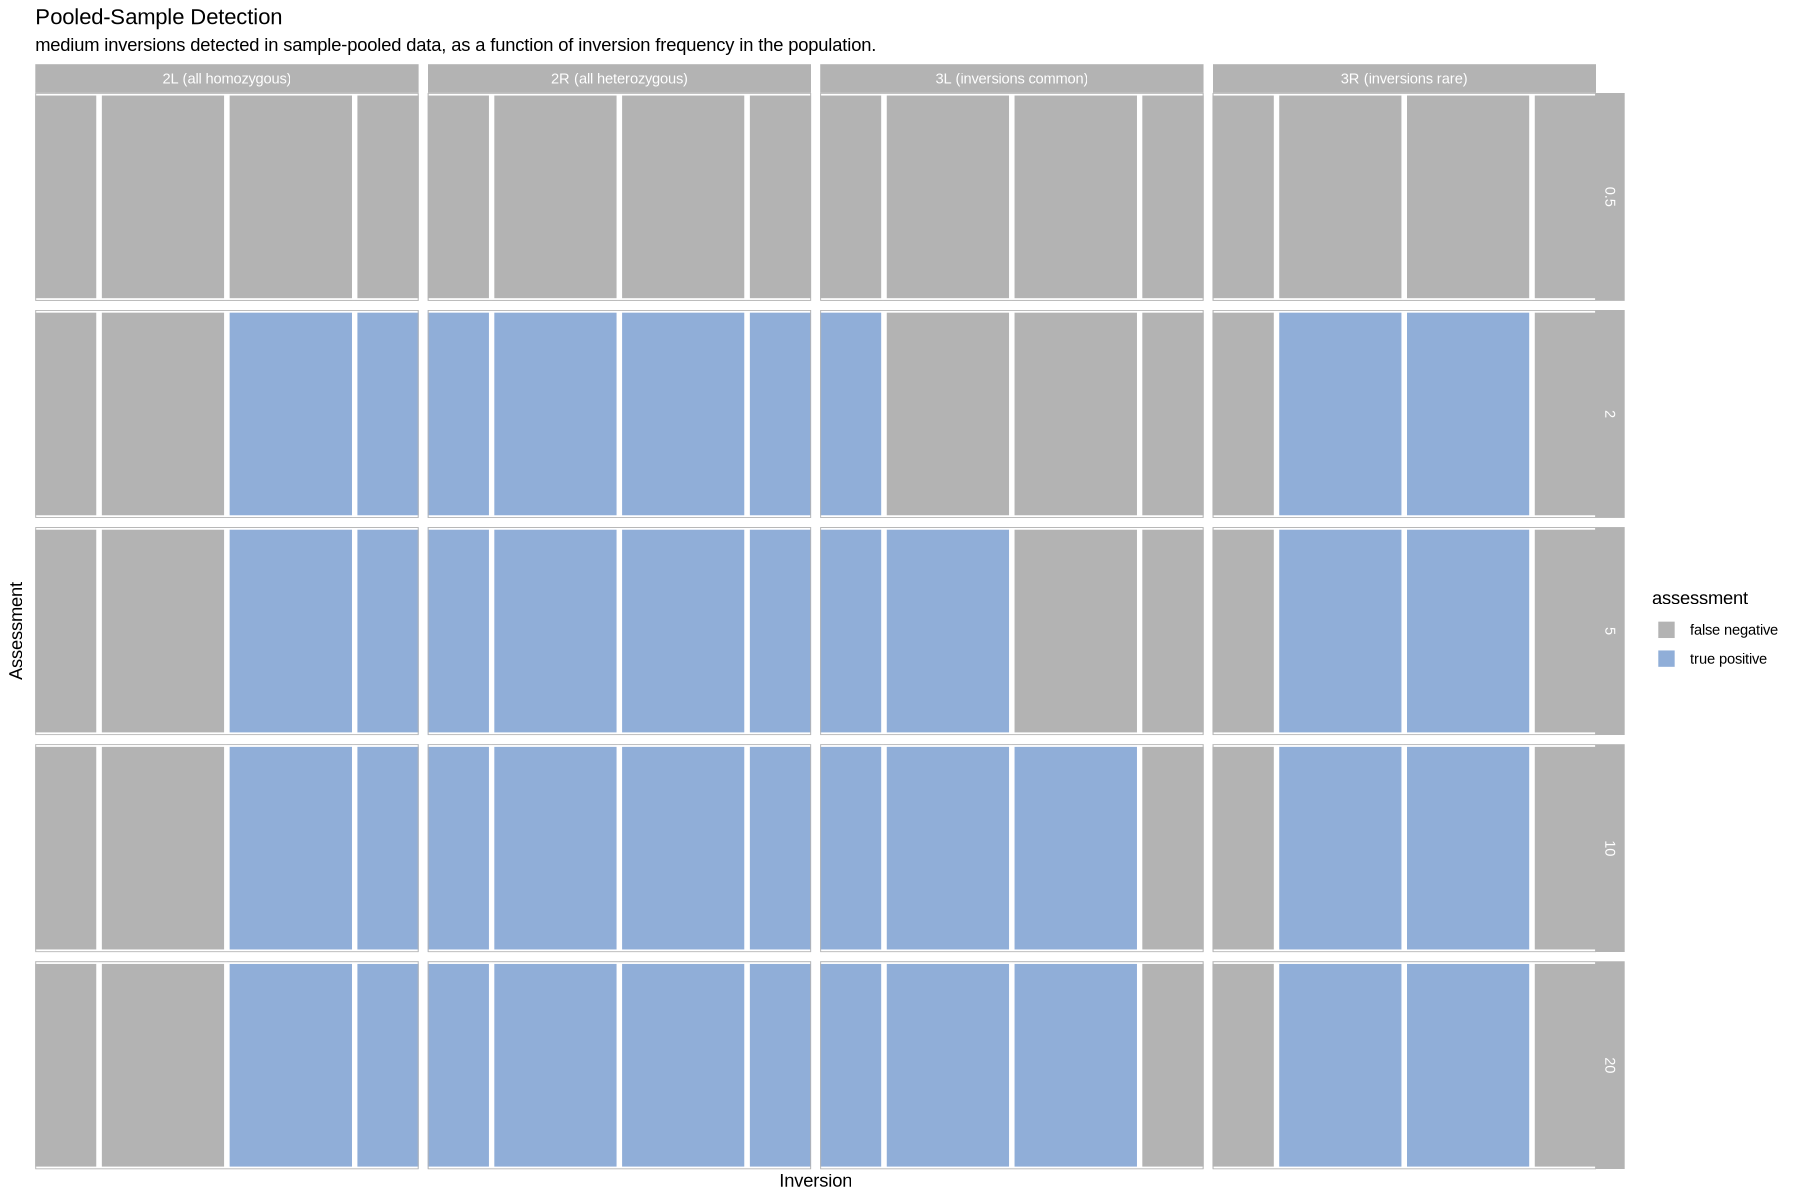

In [21]:
plot_pools_matrix(performance, .size)

Write this all to a file to tease apart later

In [ ]:
write.csv(performance, file = paste0(.size, ".sv.assessment"), quote = F, row.names = F)

[1] TRUE